In [1]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis

In [2]:
def compute_radial_spectrum(fld, dx, dy, dtype=float):
    nx, ny = fld.shape

    # Fourier wavenumbers
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K_perp = np.sqrt(KX**2 + KY**2)

    # Power spectrum density
    ff = np.abs(np.fft.ifft2(fld))**2   # use fft2, not ifft2
    P_flat = ff.ravel()
    K_flat = K_perp.ravel()

    # Radial bins
    dk = kx[1] - kx[0]
    k_bins = np.arange(0, np.max(K_flat) + dk, dk)
    nk = len(k_bins)
    P_k = np.zeros(nk, dtype=dtype)

    # Bin indices (vectorized)
    idx_float = K_flat / dk
    i1 = np.floor(idx_float).astype(int)
    i2 = i1 + 1
    w = idx_float - i1   # weight to upper bin

    # Accumulate into bins
    for i in range(len(K_flat)):
        if i1[i] >= 0 and i2[i] < nk:
            P_k[i1[i]] += P_flat[i] * (1 - w[i])
            P_k[i2[i]] += P_flat[i] * w[i]

    # Pack into recarray
    tags = ['kk', 'sp']
    sps = np.recarray((nk,), dtype=[(t, dtype) for t in tags])
    sps['kk'] = k_bins
    sps['sp'] = P_k / dk

    return sps

def partial_x_2d(f,dx):
    """Compute ∂f/∂x using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dx = np.zeros_like(f)
    
    # Central difference in x-direction (axis=0)
    df_dx[1:Nx-1, :] = (f[2:Nx, :] - f[0:Nx-2, :]) / (2 * dx)
    
    # Periodic boundaries (x-direction)
    df_dx[0, :] = (f[1, :] - f[-1, :]) / (2 * dx)
    df_dx[-1, :] = (f[0, :] - f[-2, :]) / (2 * dx)
    
    return df_dx

def partial_y_2d(f,dy):
    """Compute ∂f/∂y using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dy = np.zeros_like(f)
    
    # Central difference in y-direction (axis=1)
    df_dy[:, 1:Ny-1] = (f[:, 2:Ny] - f[:, 0:Ny-2]) / (2 * dy)
    
    # Periodic boundaries (y-direction)
    df_dy[:, 0] = (f[:, 1] - f[:, -1]) / (2 * dy)
    df_dy[:, -1] = (f[:, 0] - f[:, -2]) / (2 * dy)
    
    return df_dy

def partial_x_fft(f, dx):
    """
    Calculate ∂f/∂x using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dx (float): Grid spacing in the x-direction.

    Returns:
        df_dx (2D np.array): Partial derivative ∂f/∂x.
    """
    nx, ny = f.shape
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi  # Wavenumbers in x
    kx = kx[:, np.newaxis]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dx_hat = 1j * kx * f_hat
    df_dx = np.fft.ifft2(df_dx_hat).real

    return np.array(df_dx)

def partial_y_fft(f, dy):
    """
    Calculate ∂f/∂y using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dy (float): Grid spacing in the y-direction.

    Returns:
        df_dy (2D np.array): Partial derivative ∂f/∂y.
    """
    nx, ny = f.shape
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi  # Wavenumbers in y
    ky = ky[np.newaxis, :]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dy_hat = 1j * ky * f_hat
    df_dy = np.fft.ifft2(df_dy_hat).real

    return df_dy

#Denoising the data
def gaussian_fft_filter_2d(J_squared, k0):
    """
    Apply a Gaussian low-pass filter in Fourier space to a 2D field.

    Parameters
    ----------
    J_squared : 2D numpy array
        Input real-space data
    k0 : float
        Filter width in k-space (grid units). Smaller = stronger smoothing.

    Returns
    -------
    J_filtered : 2D numpy array
        Smoothed real-space data
    """

    # FFT
    F = np.fft.fft2(J_squared)
    F_shifted = np.fft.fftshift(F)

    # k-grid
    nx, ny = J_squared.shape
    kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
    ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2 + KY**2

    # Gaussian filter in k-space
    gaussian = np.exp(-K2 / (2 * k0**2))

    # Apply filter
    F_filt = F_shifted * gaussian

    # Inverse FFT
    F_filt = np.fft.ifftshift(F_filt)
    J_filtered = np.fft.ifft2(F_filt)

    # Return real part
    return np.real(J_filtered)

In [3]:
# List of simulation directories

dx = 0.0625
dy = 0.0625

In [4]:
# Plotting Power Spectrum at reconnection time

base_path = "/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1"

max_turbulence_time = 253

File_Bx = f"{base_path}/Bx_ApJ_t{max_turbulence_time}.h5"
File_By = f"{base_path}/By_ApJ_t{max_turbulence_time}.h5"
File_Bz = f"{base_path}/Bz_ApJ_t{max_turbulence_time}.h5"
File_Dn = f"{base_path}/Dn1_ApJ_t{max_turbulence_time}.h5"


with h5py.File(File_Bx, 'r') as fBx, \
         h5py.File(File_By, 'r') as fBy, \
         h5py.File(File_Bz, 'r') as fBz:

        data_Bx = fBx['DS1'][:].T
        data_By = fBy['DS1'][:].T
        data_Bz = fBz['DS1'][:].T

with h5py.File(File_Dn, 'r') as fDn:
    data_Dn = fDn['DS1'][:].T

data_Jx =  partial_y_fft(data_Bz, dx)
data_Jy = -partial_x_fft(data_Bz, dx)
data_Jz =  partial_x_fft(data_By, dx) - partial_y_fft(data_Bx, dx)

# # Compute radial spectra
# spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
# spectrum_By = compute_radial_spectrum(data_By, dx, dy)
# spectrum_Bz = compute_radial_spectrum(data_Bz, dx, dy)

# spectrum_Jx = compute_radial_spectrum(data_Jx, dx, dy)
# spectrum_Jy = compute_radial_spectrum(data_Jy, dx, dy)
# spectrum_Jz = compute_radial_spectrum(data_Jz, dx, dy)


# spectrum_B = np.recarray(spectrum_Bx.shape, dtype=spectrum_Bx.dtype)
# spectrum_B.kk = spectrum_Bx.kk
# spectrum_B.sp = spectrum_Bx.sp + spectrum_By.sp + spectrum_Bz.sp

# spectrum_J = np.recarray(spectrum_Jx.shape, dtype=spectrum_Jx.dtype)
# spectrum_J.kk = spectrum_Jx.kk
# spectrum_J.sp = spectrum_Jx.sp + spectrum_Jy.sp + spectrum_Jz.sp

In [5]:
#Spectrum after filtering

data_Bx_filtered = gaussian_fft_filter_2d(data_Bx, k0=0.3 * len(data_Bx))
data_By_filtered = gaussian_fft_filter_2d(data_By, k0=0.3 * len(data_Bx))
data_Bz_filtered = gaussian_fft_filter_2d(data_Bz, k0=0.3 * len(data_Bx))

data_Bx = data_Bx_filtered
data_By = data_By_filtered
data_Bz = data_Bz_filtered

data_Jx = partial_y_fft(data_Bz_filtered,dx)
data_Jy = -partial_x_fft(data_Bz_filtered,dy)
data_Jz = partial_x_fft(data_By_filtered,dy)-partial_y_fft(data_Bx_filtered,dx)

# Compute radial spectra
spectrum_Bxf = compute_radial_spectrum(data_Bx, dx, dy)
spectrum_Byf = compute_radial_spectrum(data_By, dx, dy)
spectrum_Bzf = compute_radial_spectrum(data_Bz, dx, dy)

spectrum_Jxf = compute_radial_spectrum(data_Jx, dx, dy)
spectrum_Jyf = compute_radial_spectrum(data_Jy, dx, dy)
spectrum_Jzf = compute_radial_spectrum(data_Jz, dx, dy)

spectrum_Bf = np.recarray(spectrum_Bxf.shape, dtype=spectrum_Bxf.dtype)
spectrum_Bf.kk = spectrum_Bxf.kk
spectrum_Bf.sp = spectrum_Bxf.sp + spectrum_Byf.sp + spectrum_Bzf.sp

spectrum_Jf = np.recarray(spectrum_Jxf.shape, dtype=spectrum_Jxf.dtype)
spectrum_Jf.kk = spectrum_Jxf.kk
spectrum_Jf.sp = spectrum_Jxf.sp + spectrum_Jyf.sp + spectrum_Jzf.sp

In [6]:
# Plot unfiltered first and capture line objects
line_J, = plt.loglog(
    spectrum_J.kk,
    spectrum_J.sp,
    label="J spectrum"
)

line_B, = plt.loglog(
    spectrum_B.kk,
    spectrum_B.sp,
    label="B spectrum"
)

# Use same colors but dotted linestyle for filtered versions
plt.loglog(
    spectrum_Jf.kk,
    spectrum_Jf.sp,
    linestyle=":",
    color=line_J.get_color(),
    label="J spectrum with filter"
)

plt.loglog(
    spectrum_Bf.kk,
    spectrum_Bf.sp,
    linestyle=":",
    color=line_B.get_color(),
    label="B spectrum with filter"
)

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.xlim(5e-2, 50)
plt.ylim(1e-6, 1)

plt.legend()
plt.tight_layout()
plt.savefig("JB_Spectrum_30", dpi=300)
plt.show()

NameError: name 'spectrum_J' is not defined

In [20]:
#Lets Computer J_total

# # 1. Read the HDF5 file
File_Bx = '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1/Bx_ApJ_t40.h5'  # Replace with your file path
File_By = '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1/By_ApJ_t40.h5'  # Replace with your file path
File_Bz = '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1/Bz_ApJ_t40.h5'  # Replace with your file path


with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy, h5py.File(File_Bz, 'r') as fBz:
    data_Bx = fBx['DS1'][:].T
    data_By = fBy['DS1'][:].T
    data_Bz = fBz['DS1'][:].T

In [21]:
data_Jx = partial_y_fft(data_Bz,dx)
data_Jy = -partial_x_fft(data_Bz,dy)
data_Jz = partial_x_fft(data_By,dy)-partial_y_fft(data_Bx,dx)

J_squared = data_Jx**2 + data_Jy**2 + data_Jz**2

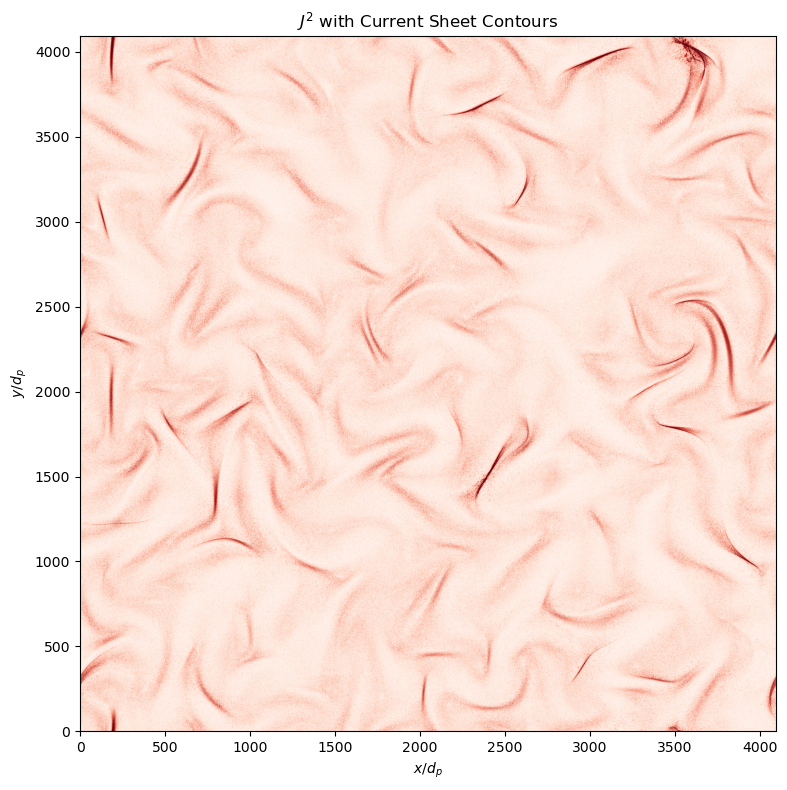

In [23]:
#Plot current sheets over the base J_squared field

plt.figure(figsize=(10, 8))

# Base field
plt.imshow(J_squared.T, cmap='Reds', origin='lower', vmax=0.5)


plt.title(r'$J^{2}$ with Current Sheet Contours')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')
plt.tight_layout()
plt.savefig("J2_without_Filter.png", dpi=300)
plt.show()

In [24]:
data_Bx_filtered = gaussian_fft_filter_2d(data_Bx, k0=0.3 * len(data_Bx))
data_By_filtered = gaussian_fft_filter_2d(data_By, k0=0.3 * len(data_Bx))
data_Bz_filtered = gaussian_fft_filter_2d(data_Bz, k0=0.3 * len(data_Bx))
data_Jx = partial_y_fft(data_Bz_filtered,dx)
data_Jy = -partial_x_fft(data_Bz_filtered,dy)
data_Jz = partial_x_fft(data_By_filtered,dy)-partial_y_fft(data_Bx_filtered,dx)

J_squared = data_Jx**2 + data_Jy**2 + data_Jz**2
J_squared = gaussian_fft_filter_2d(J_squared, k0=0.3 * len(data_Bx))

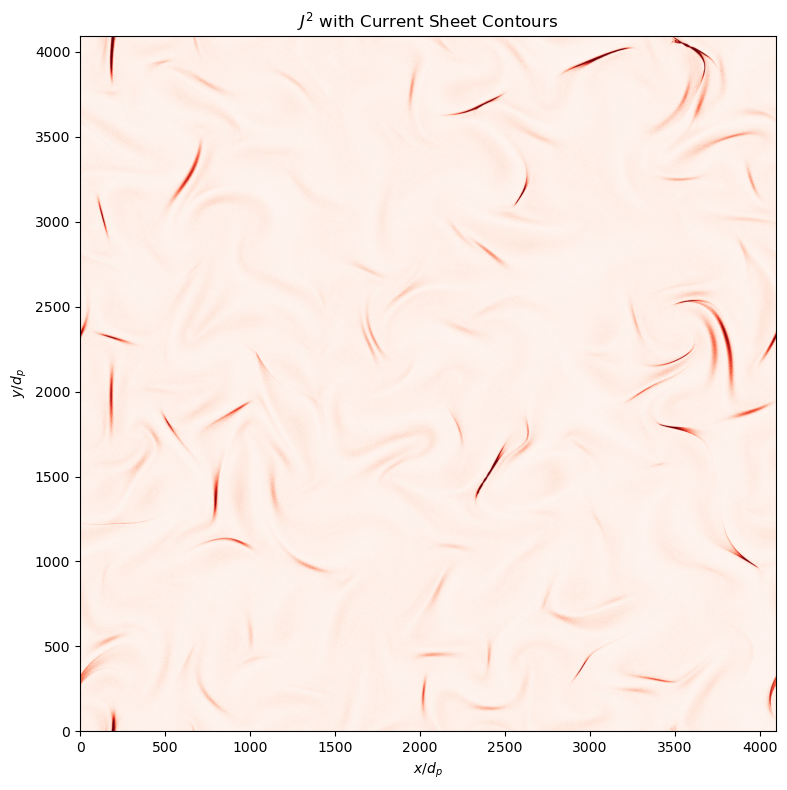

In [25]:
#Plot current sheets over the base J_squared field

plt.figure(figsize=(10, 8))

# Base field
plt.imshow(J_squared.T, cmap='Reds', origin='lower', vmax=0.5)


plt.title(r'$J^{2}$ with Current Sheet Contours')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')
plt.tight_layout()
plt.savefig("J2_with_Filter.png", dpi=300)
plt.show()